In [1]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print(
    "Device:",
    "CUDA" if torch.cuda.is_available() else "CPU"
)

PyTorch version: 2.14.1+cpu
Torchvision version: 0.29.1+cpu
Device: CPU


In [2]:
from torchvision import transforms

train_augmentation = transforms.Compose([
    
    # Small rotation
    transforms.RandomRotation(
        degrees=10
    ),

    # Horizontal flip
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    # Small changes to brightness, contrast,
    # saturation and color
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Convert image to PyTorch tensor
    transforms.ToTensor()
])

print(train_augmentation)

Compose(
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
)


In [4]:
from pathlib import Path

preprocessed_dir = Path(
    "../data/processed/classification_preprocessed"
)

print("Preprocessed dataset:", preprocessed_dir)
print("Exists:", preprocessed_dir.exists())

Preprocessed dataset: ..\data\processed\classification_preprocessed
Exists: True


In [5]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = next(
    (preprocessed_dir / "train" / "aqua").glob("*.jpg")
)

sample_image = Image.open(
    sample_path
).convert("RGB")

print("Image:", sample_path.name)
print("Size:", sample_image.size)

Image: aqua (1)_object_1.jpg
Size: (224, 224)


In [6]:
augmented_images = []

for i in range(4):
    augmented = train_augmentation(sample_image)
    augmented_images.append(augmented)

print(
    "Augmented images created:",
    len(augmented_images)
)

Augmented images created: 4


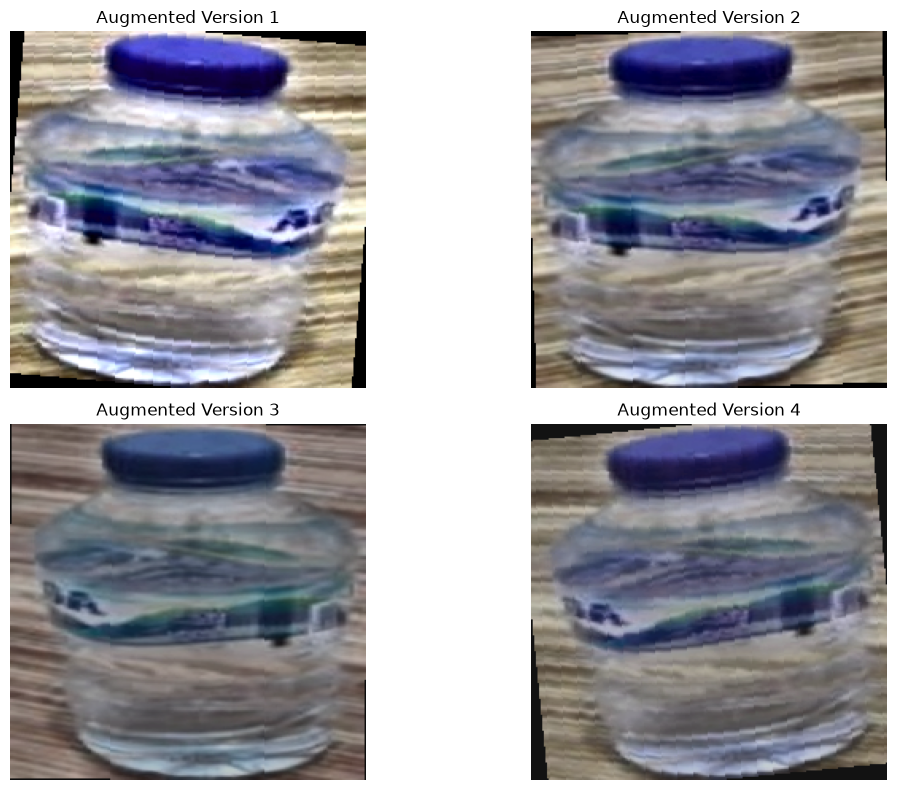

In [7]:
plt.figure(figsize=(12, 8))

for i, image_tensor in enumerate(augmented_images):

    image = image_tensor.permute(
        1, 2, 0
    ).numpy()

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Augmented Version {i + 1}"
    )

plt.tight_layout()
plt.show()

In [8]:
# Create one augmented version
augmented_tensor = train_augmentation(sample_image)

# Convert tensor back to image format
augmented_image = (
    augmented_tensor
    .permute(1, 2, 0)
    .numpy()
)

print("Original size:", sample_image.size)
print("Augmented shape:", augmented_image.shape)

Original size: (224, 224)
Augmented shape: (224, 224, 3)


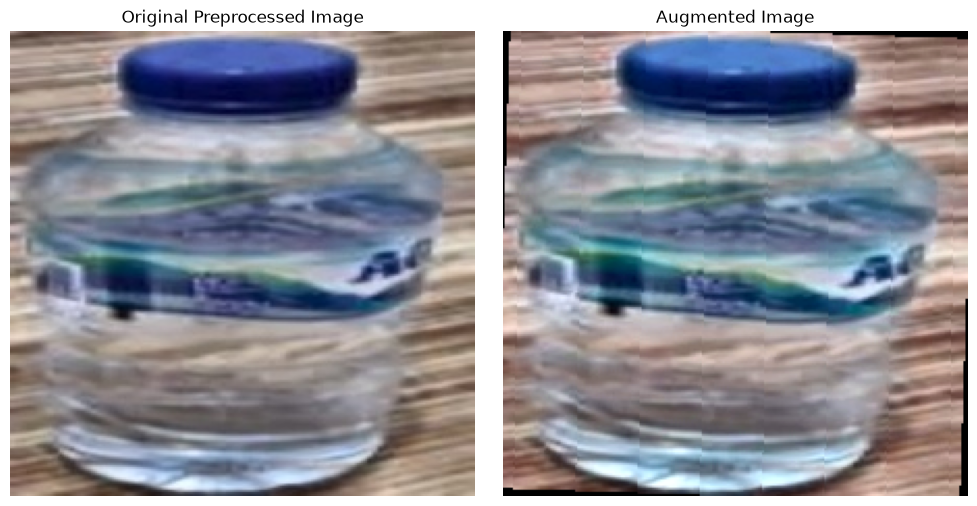

In [9]:
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.axis("off")
plt.title("Original Preprocessed Image")

# Augmented
plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.axis("off")
plt.title("Augmented Image")

plt.tight_layout()
plt.show()

In [10]:
train_augmentation = transforms.Compose([
    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor()
])